In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data_dir = "/Users/cul434/Library/CloudStorage/Dropbox/Jellyfish_Data"
datasets = ["Homeostasis_1", "Homeostasis_2", "Regeneration_1", "Regeneration_2"]
n_datasets = len(datasets)

## Birth and death "census"

In [3]:
# compute birth and death datasets for each dataset, which contain the time and position of each birth and death event, respectively
birth_datasets = {}
death_datasets = {}
neuron_dfs = {}
for dataset in datasets:
    neurons = pd.read_csv(data_dir + "/" + dataset + "/final_nomouth_processed.csv")
    neuron_dfs[dataset] = neurons
    births = neurons.groupby("track_id", as_index=False).first()
    births = births[["track_id", "real_time", "x", "y", "r", "theta", "jump"]].copy()
    #need to remove tracks that start at the first timepoint, since these represent the start of tracking, not actual birth events
    min_time = neurons["real_time"].min()
    births = births[ births["real_time"] > min_time]
    birth_datasets[dataset] = births
    
    deaths = neurons.groupby("track_id", as_index=False).last() # this attributes death time to the last time the neuron was observed alive 
    deaths = deaths[["track_id", "real_time", "x", "y", "r", "theta", "jump"]].copy()
    #need to remove tracks that end at the last timepoint, since these represent the end of tracking, not actual death events
    max_time = neurons["real_time"].max()   
    deaths = deaths[deaths["real_time"] < max_time]
    death_datasets[dataset] = deaths



In [4]:
# total births and deaths for each dataset 

for dataset in datasets:
    max_time = neuron_dfs[dataset]["real_time"].max()
    print(f"{dataset}: total births = {len(birth_datasets[dataset])}, total deaths = {len(death_datasets[dataset])}, total neurons = {len(neuron_dfs[dataset]['track_id'].unique())}, final neurons = {len(neuron_dfs[dataset][neuron_dfs[dataset]['real_time'] == max_time])}")

Homeostasis_1: total births = 238, total deaths = 132, total neurons = 361, final neurons = 229
Homeostasis_2: total births = 206, total deaths = 54, total neurons = 364, final neurons = 310
Regeneration_1: total births = 317, total deaths = 0, total neurons = 318, final neurons = 318
Regeneration_2: total births = 363, total deaths = 15, total neurons = 364, final neurons = 349


In [5]:
# overall birth and death rates (total events divided by total time and total neurons)
for dataset in datasets:
    total_time = neuron_dfs[dataset]["real_time"].max() - neuron_dfs[dataset]["real_time"].min()
    total_neurons = len(neuron_dfs[dataset]['track_id'].unique())
    birth_rate = len(birth_datasets[dataset]) / (total_time * total_neurons)
    death_rate = len(death_datasets[dataset]) / (total_time * total_neurons)
    print(f"{dataset}: overall birth rate = {birth_rate:.6f} per neuron per hour, overall death rate = {death_rate:.6f} per neuron per hour")

Homeostasis_1: overall birth rate = 0.005587 per neuron per hour, overall death rate = 0.003099 per neuron per hour
Homeostasis_2: overall birth rate = 0.005023 per neuron per hour, overall death rate = 0.001317 per neuron per hour
Regeneration_1: overall birth rate = 0.008744 per neuron per hour, overall death rate = 0.000000 per neuron per hour
Regeneration_2: overall birth rate = 0.007811 per neuron per hour, overall death rate = 0.000323 per neuron per hour


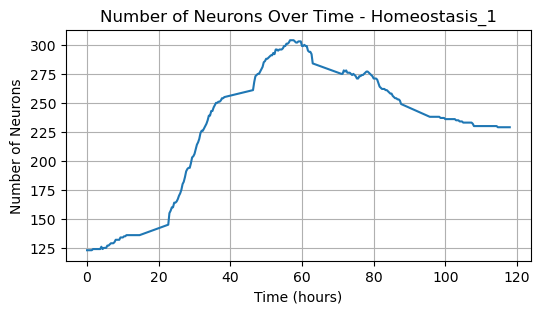

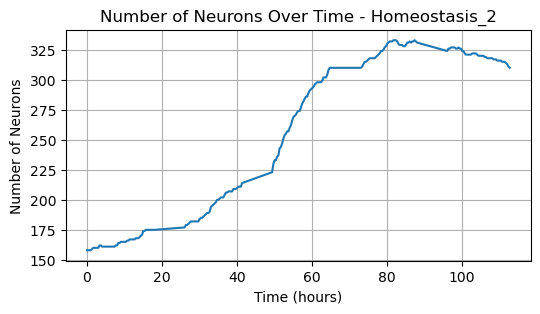

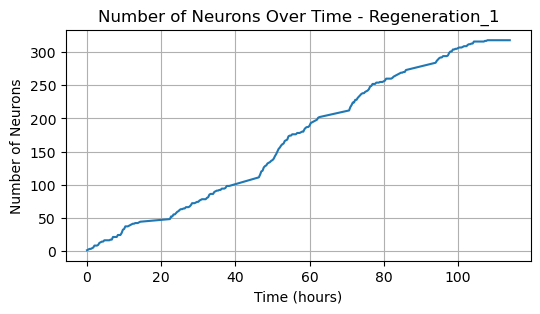

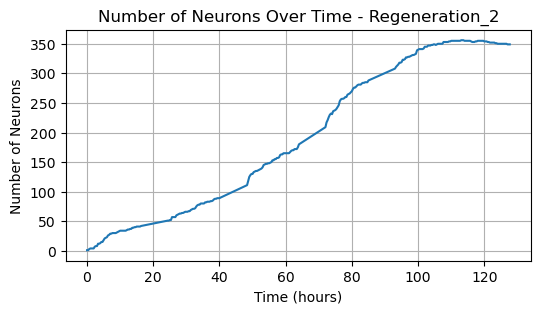

In [6]:
# plot number of neurons over time for all datasets 

for dataset in datasets:
    neurons = neuron_dfs[dataset]
    neuron_counts = neurons.groupby("real_time")["track_id"].nunique().reset_index()
    plt.figure(figsize=(6, 3))
    sns.lineplot(data=neuron_counts, x="real_time", y="track_id")
    plt.title(f"Number of Neurons Over Time - {dataset}")
    plt.xlabel("Time (hours)")
    plt.ylabel("Number of Neurons")
    plt.grid()
    plt.show()

## Spatial Binning

count the number of neurons, births, and deaths at each distance from the mouth. 

In [7]:
n_bins = 20

radial_density = {}

for dataset in datasets:
    neurons = neuron_dfs[dataset]
    births = birth_datasets[dataset]
    deaths = death_datasets[dataset]

    # determine r_max and normalize radius by it
    all_r = pd.concat([neurons["r"], births["r"], deaths["r"]]).dropna()
    r_max = all_r.max()
    r_min_norm = all_r.min() / r_max
    bin_edges = np.linspace(r_min_norm, 1.0, n_bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # annulus areas for each radial bin (in normalized units)
    bin_areas = np.pi * (bin_edges[1:]**2 - bin_edges[:-1]**2)

    time_points = neurons["real_time"].dropna().unique()
    time_points.sort()

    # arrays of shape (n_timepoints, n_bins)
    neuron_hist = np.zeros((len(time_points), n_bins))
    birth_hist  = np.zeros((len(time_points), n_bins))
    death_hist  = np.zeros((len(time_points), n_bins))

    for i, t in enumerate(time_points):
        nr = neurons.loc[neurons["real_time"] == t, "r"].dropna().to_numpy() / r_max
        br = births.loc[births["real_time"] == t, "r"].dropna().to_numpy() / r_max
        dr = deaths.loc[deaths["real_time"] == t, "r"].dropna().to_numpy() / r_max

        if nr.size > 0:
            counts, _ = np.histogram(nr, bins=bin_edges, density=False)
            neuron_hist[i] = counts / bin_areas

        if br.size > 0:
            counts, _ = np.histogram(br, bins=bin_edges, density=False)
            birth_hist[i] = counts / bin_areas

        if dr.size > 0:
            counts, _ = np.histogram(dr, bins=bin_edges, density=False)
            death_hist[i] = counts / bin_areas

    radial_density[dataset] = {
        "time_points": time_points,
        "bin_edges": bin_edges,
        "bin_centers": bin_centers,
        "bin_areas": bin_areas,
        "r_max": r_max,
        "neuron_hist": neuron_hist,  # units: count per normalized area
        "birth_hist":  birth_hist,
        "death_hist":  death_hist,
    }


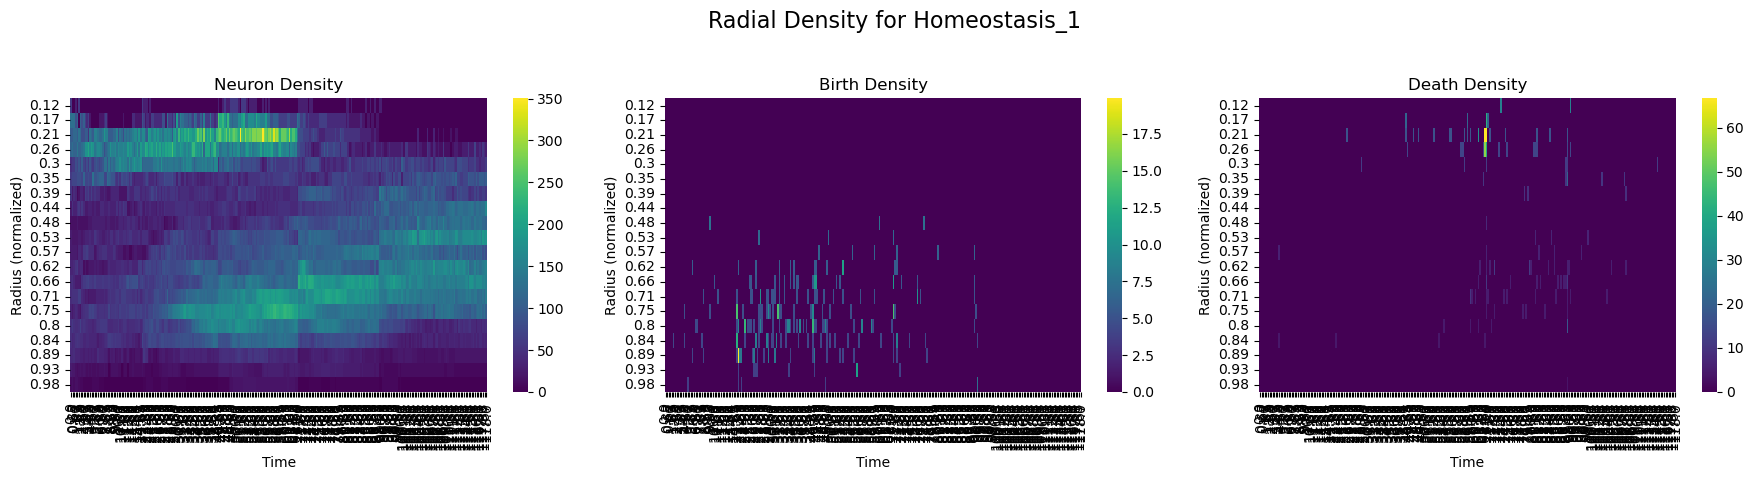

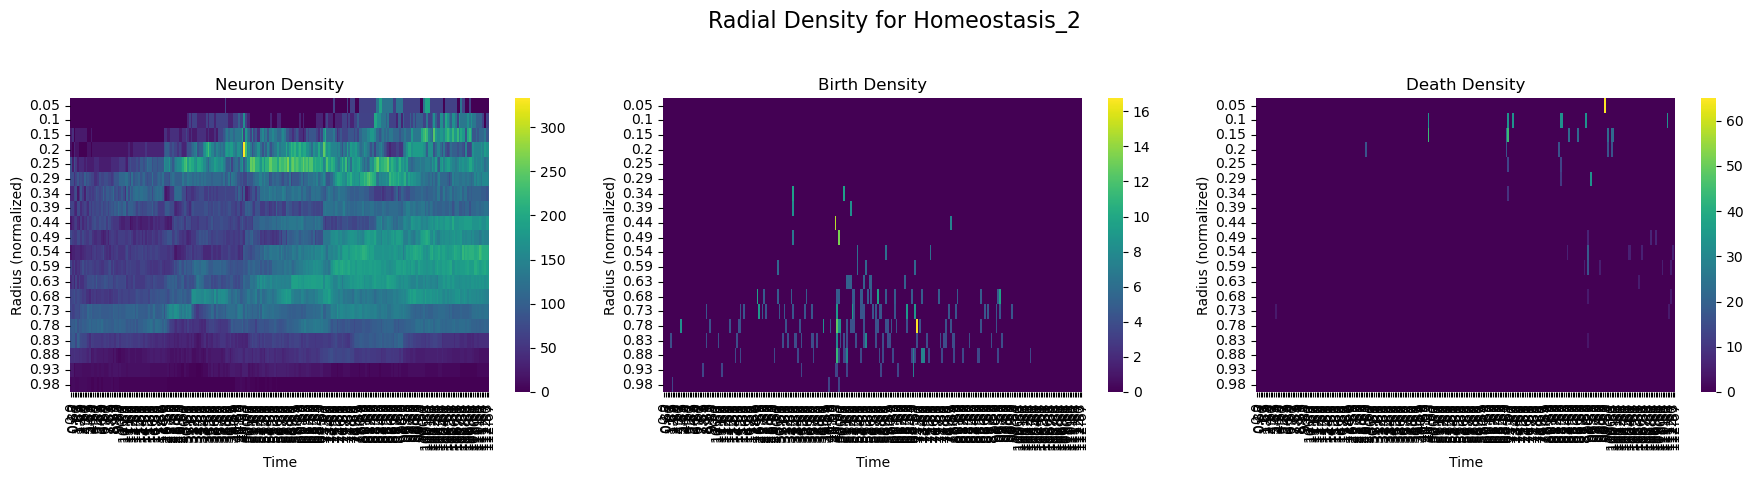

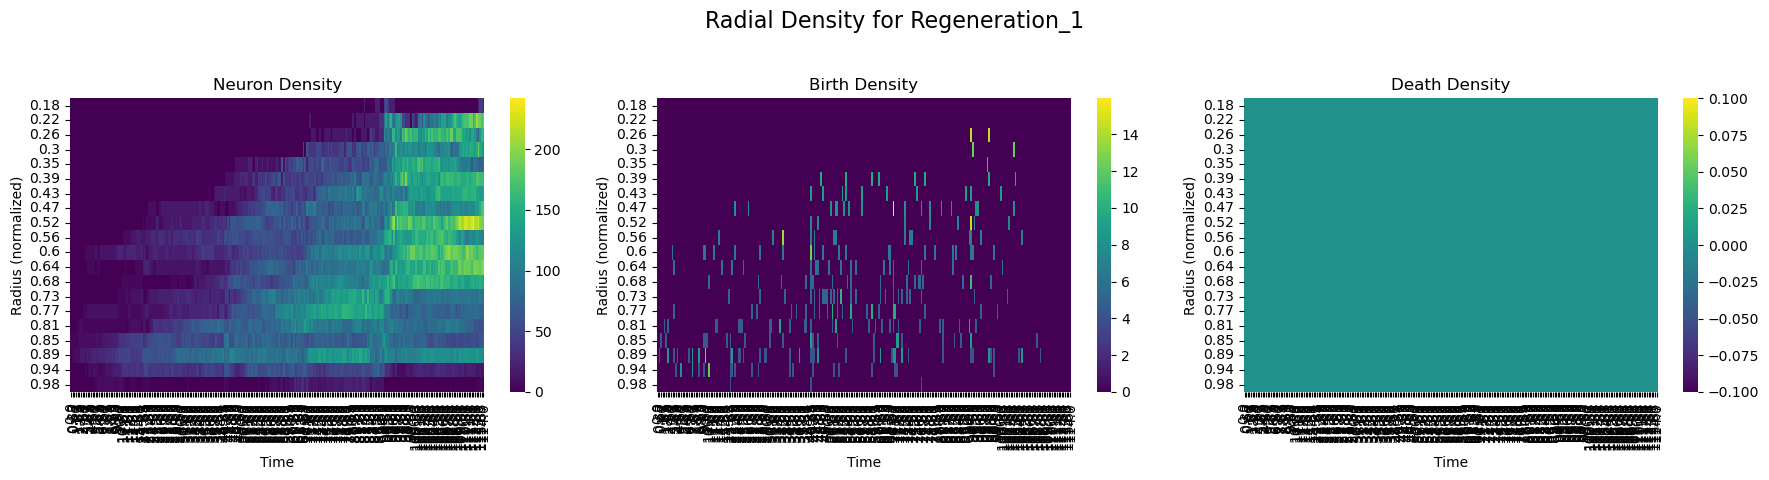

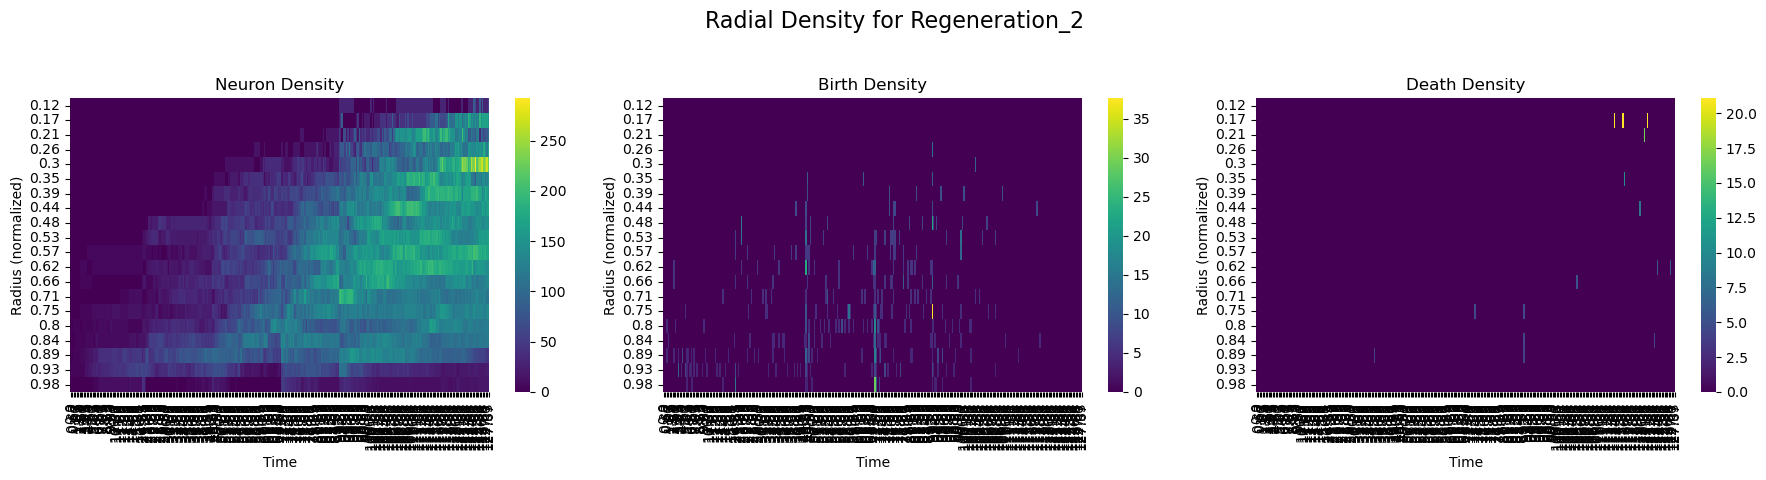

In [8]:
#plot the density of neurons, births, and deaths as a function of radius and time for each dataset
for dataset in datasets:
    data = radial_density[dataset]
    time_points = data["time_points"]
    bin_centers = data["bin_centers"]
    neuron_hist = data["neuron_hist"]
    birth_hist = data["birth_hist"]
    death_hist = data["death_hist"]

    plt.figure(figsize=(18, 5))
    plt.suptitle(f"Radial Density for {dataset}", fontsize=16)

    plt.subplot(1, 3, 1)
    sns.heatmap(neuron_hist.T, xticklabels=np.round(time_points, 2), yticklabels=np.round(bin_centers, 2), cmap="viridis")
    plt.title("Neuron Density")
    plt.xlabel("Time")
    plt.ylabel("Radius (normalized)")

    plt.subplot(1, 3, 2)
    sns.heatmap(birth_hist.T, xticklabels=np.round(time_points, 2), yticklabels=np.round(bin_centers, 2), cmap="viridis")
    plt.title("Birth Density")
    plt.xlabel("Time")
    plt.ylabel("Radius (normalized)")

    plt.subplot(1, 3, 3)
    sns.heatmap(death_hist.T, xticklabels=np.round(time_points, 2), yticklabels=np.round(bin_centers, 2), cmap="viridis")
    plt.title("Death Density")
    plt.xlabel("Time")
    plt.ylabel("Radius (normalized)")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


In [9]:
test_dataset = datasets[0]
radial_density[test_dataset].keys()


dict_keys(['time_points', 'bin_edges', 'bin_centers', 'bin_areas', 'r_max', 'neuron_hist', 'birth_hist', 'death_hist'])

## Determine radius-dependent death rate 

Homeostasis_1: overall death rate from histograms = 0.006349 per neuron per hour, overall death rate from totals = 0.003099 per neuron per hour


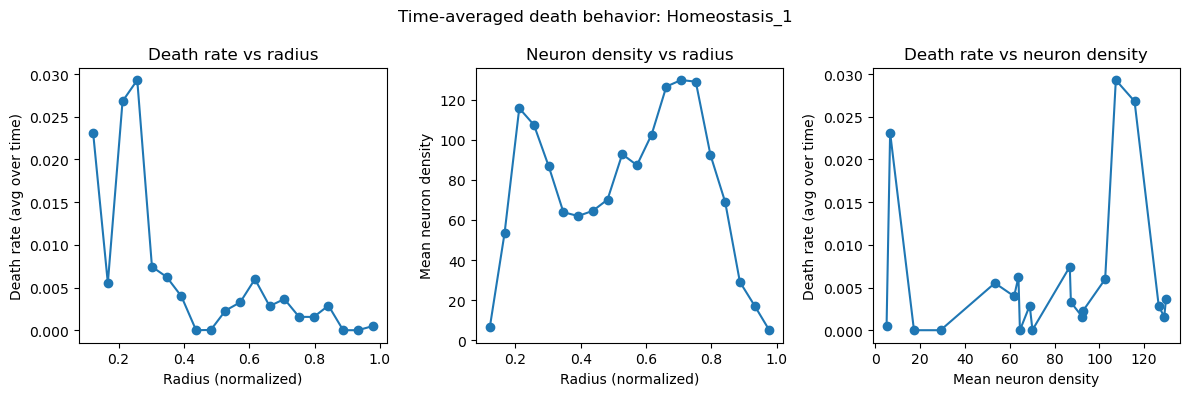

Homeostasis_2: overall death rate from histograms = 0.003032 per neuron per hour, overall death rate from totals = 0.001317 per neuron per hour


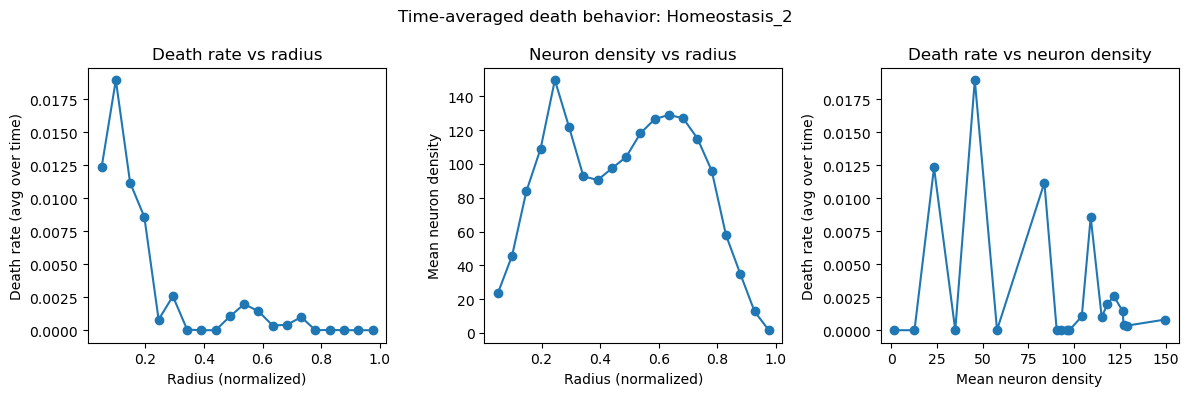

Regeneration_1: overall death rate from histograms = 0.000000 per neuron per hour, overall death rate from totals = 0.000000 per neuron per hour


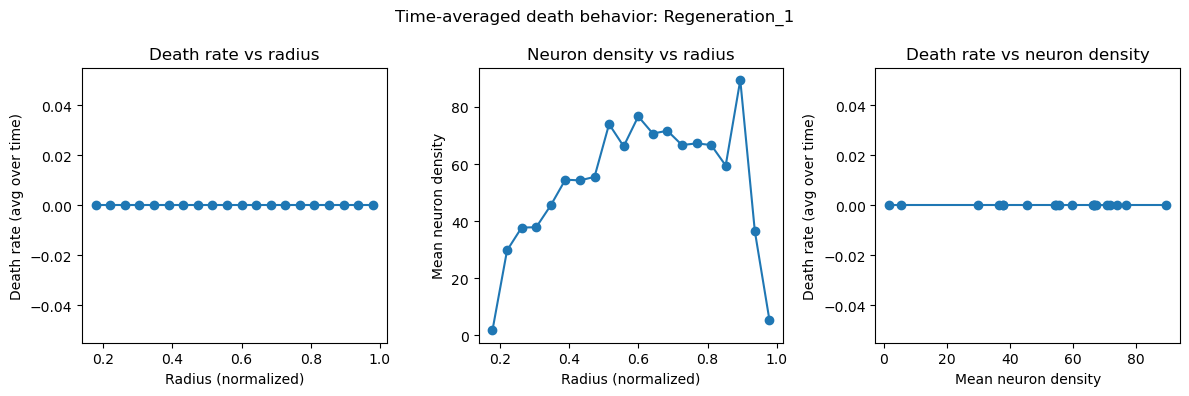

Regeneration_2: overall death rate from histograms = 0.000594 per neuron per hour, overall death rate from totals = 0.000323 per neuron per hour


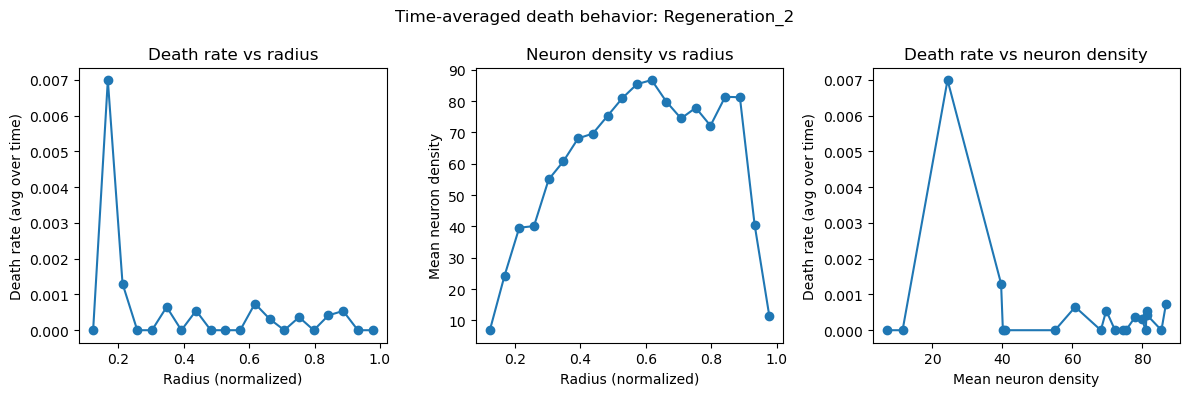

In [10]:
# for each dataset, for each radial bin, for each time point, compute the death rate as the ratio of death density to neuron density (with a small epsilon to avoid division by zero), then average this death rate over time for each radial bin. Then examine how this time-averaged death rate varies with radius and with mean neuron density across radial bins.
for dataset in datasets:
    data = radial_density[dataset]
    bin_centers = data["bin_centers"]  # already normalized
    neuron_hist = data["neuron_hist"]   # shape: (time, radius_bin)
    death_hist = data["death_hist"]     # shape: (time, radius_bin)
    time_points = data["time_points"]   

    epsilon = 1e-10


    spatial_death_rates = np.zeros_like(death_hist[:-1, :])  # shape: (time, radius_bin) (-1 because we compute rates between time points)
    for i, time in enumerate(time_points[:-1]):
        neuron_density  = neuron_hist[i, :]
        death_density = death_hist[i, :] 
        dt = time_points[i+1] - time_points[i] 
        spatial_death_rates[i] = death_density / ((neuron_density + epsilon) * dt)  # units: deaths per neuron per hour at each time point and radial bin
    # time-averaged death rate per radial bin
    death_rate_avg = spatial_death_rates.mean(axis=0)
    mean_neuron_density = neuron_hist.mean(axis=0)
    total_deaths =  death_datasets[dataset].shape[0]
    total_neurons = neuron_dfs[dataset]['track_id'].nunique()
    total_time = time_points[-1] - time_points[0]

    overall_death_rate = total_deaths / (total_neurons * total_time)  # units: deaths per neuron per hour
 
    print(f"{dataset}: overall death rate from histograms = {death_rate_avg.mean():.6f} per neuron per hour, overall death rate from totals = {overall_death_rate:.6f} per neuron per hour")
    
    data["spatial_death_rate"] = death_rate_avg

    plt.figure(figsize=(12, 4))
    plt.suptitle(f"Time-averaged death behavior: {dataset}")

    # death rate vs radius
    plt.subplot(1, 3, 1)
    plt.plot(bin_centers, death_rate_avg, marker="o")
    plt.xlabel("Radius (normalized)")
    plt.ylabel("Death rate (avg over time)")
    plt.title("Death rate vs radius")

    plt.subplot(1, 3, 3)

    # density vs radius
    plt.subplot(1, 3, 2)
    plt.plot(bin_centers, mean_neuron_density, marker="o")
    plt.xlabel("Radius (normalized)")
    plt.ylabel("Mean neuron density")
    plt.title("Neuron density vs radius")


    # death rate vs neuron density (one point per radial bin)
    plt.subplot(1, 3, 3)
    # sort by mean neuron density for better visualization
    sorted_indices = np.argsort(mean_neuron_density)
    mean_neuron_density = mean_neuron_density[sorted_indices]
    death_rate_avg = death_rate_avg[sorted_indices]
    plt.plot(mean_neuron_density, death_rate_avg, marker="o")
    plt.xlabel("Mean neuron density")
    plt.ylabel("Death rate (avg over time)")
    plt.title("Death rate vs neuron density")

    

    plt.tight_layout()
    plt.show()


Based on this, it looks like death rate depends on radius, not density. 

 I'd like to fit a curve of the form d(r) = c * exp(-r) to the death rate

Fitted c1 for Homeostasis_1: c1=0.00279852
Fitted c1 for Homeostasis_2: c1=0.00090257
Fitted c1 for Regeneration_1: c1=0.00000000
Fitted c1 for Regeneration_2: c1=0.00027702


/var/folders/87/w43tb79n67n08xyspfl0n8390zhhg9/T/ipykernel_65386/2025638166.py:13: RuntimeWarning: divide by zero encountered in divide
  return c1 * 1/np.abs(radius)
/var/folders/87/w43tb79n67n08xyspfl0n8390zhhg9/T/ipykernel_65386/2025638166.py:13: RuntimeWarning: invalid value encountered in divide
  return c1 * 1/np.abs(radius)


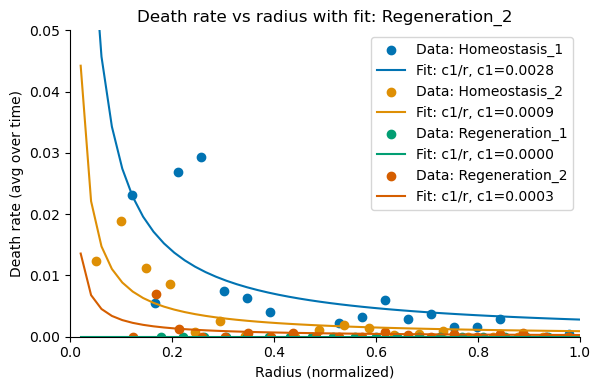

In [11]:
from scipy.optimize import curve_fit

plt.figure(figsize=(6, 4))
palette = sns.color_palette("colorblind", n_datasets)

for dataset in datasets:
    data = radial_density[dataset]
    bin_centers = data["bin_centers"]  # already normalized
    spatial_death_rate = data["spatial_death_rate"]  # shape: radius_bins 
    
    # fit curve of the form d(r) = c /r
    def one_over_r_funct(radius, c1):
                return c1 * 1/np.abs(radius) 
            
    popt, pcov = curve_fit(one_over_r_funct, bin_centers, spatial_death_rate)
    c1_fit = popt[0]
    print(f"Fitted c1 for {dataset}: c1={c1_fit:.8f}")
    
    # plot data and fitted curve
    r_vals = np.linspace(0, 1, 50)
    plt.scatter(bin_centers, spatial_death_rate, marker="o", label="Data: " + dataset, color = palette[datasets.index(dataset)])
    plt.plot(r_vals, one_over_r_funct(r_vals, c1_fit), label=f"Fit: c1/r, c1={c1_fit:.4f}", color = palette[datasets.index(dataset)])
    plt.xlabel("Radius (normalized)")
    plt.ylabel("Death rate (avg over time)")
    plt.title(f"Death rate vs radius with fit: {dataset}")
    plt.legend()
    plt.tight_layout()
    sns.despine()
plt.xlim(0, 1)
plt.ylim(0, 0.05)
plt.show()


## Next step: drift and diffusion rates 

Calculating drift and diffusion estimates for time interval of 5 time steps (1.67 hours)
Homeostasis_1: Estimated drift = -0.001618 radius units per hour, Estimated diffusion = 0.000034 radius units^2 per hour
Homeostasis_1: With drift alone, at this rate, it would take 618.12 hours, i.e. 25.76 days for a neuron to cross the jellyfish
Homeostasis_1: typical cohort size = 0.00 neurons
Homeostasis_2: Estimated drift = -0.002404 radius units per hour, Estimated diffusion = 0.000041 radius units^2 per hour
Homeostasis_2: With drift alone, at this rate, it would take 415.91 hours, i.e. 17.33 days for a neuron to cross the jellyfish
Homeostasis_2: typical cohort size = 11.36 neurons
Regeneration_1: Estimated drift = -0.001976 radius units per hour, Estimated diffusion = 0.000037 radius units^2 per hour
Regeneration_1: With drift alone, at this rate, it would take 506.07 hours, i.e. 21.09 days for a neuron to cross the jellyfish
Regeneration_1: typical cohort size = 23.96 neurons
Regeneration

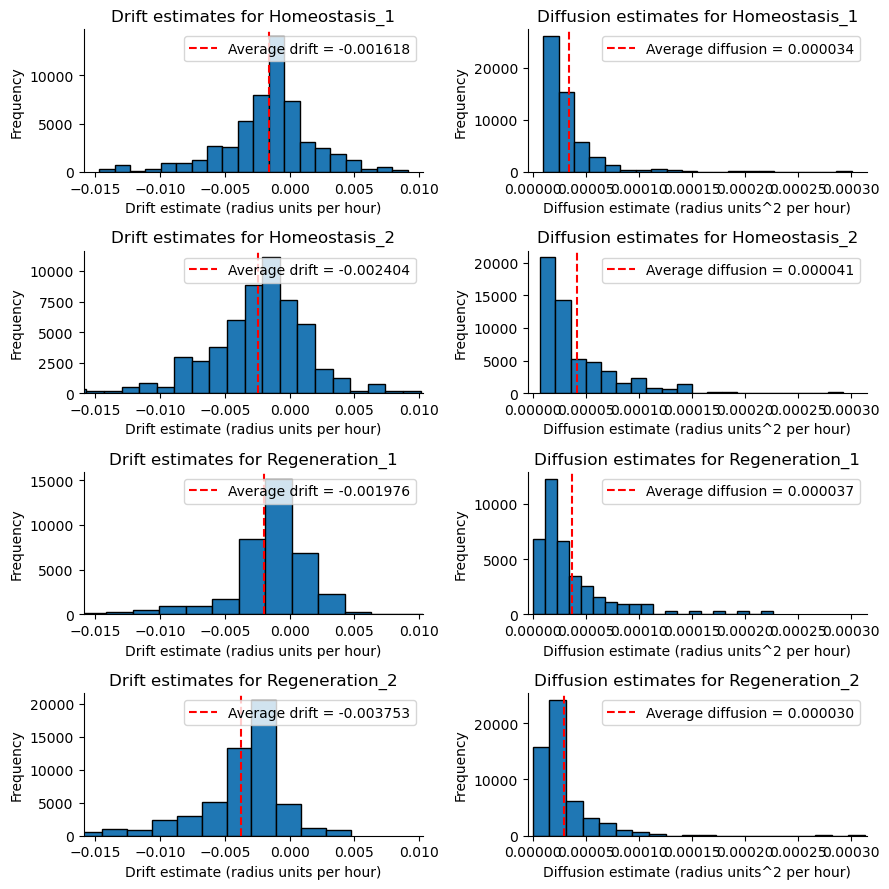

Calculating drift and diffusion estimates for time interval of 10 time steps (3.33 hours)
Homeostasis_1: Estimated drift = -0.001591 radius units per hour, Estimated diffusion = 0.000032 radius units^2 per hour
Homeostasis_1: With drift alone, at this rate, it would take 628.61 hours, i.e. 26.19 days for a neuron to cross the jellyfish
Homeostasis_1: typical cohort size = 42.67 neurons
Homeostasis_2: Estimated drift = -0.002375 radius units per hour, Estimated diffusion = 0.000038 radius units^2 per hour
Homeostasis_2: With drift alone, at this rate, it would take 420.98 hours, i.e. 17.54 days for a neuron to cross the jellyfish
Homeostasis_2: typical cohort size = 53.92 neurons
Regeneration_1: Estimated drift = -0.001446 radius units per hour, Estimated diffusion = 0.000032 radius units^2 per hour
Regeneration_1: With drift alone, at this rate, it would take 691.58 hours, i.e. 28.82 days for a neuron to cross the jellyfish
Regeneration_1: typical cohort size = 66.40 neurons
Regenerati

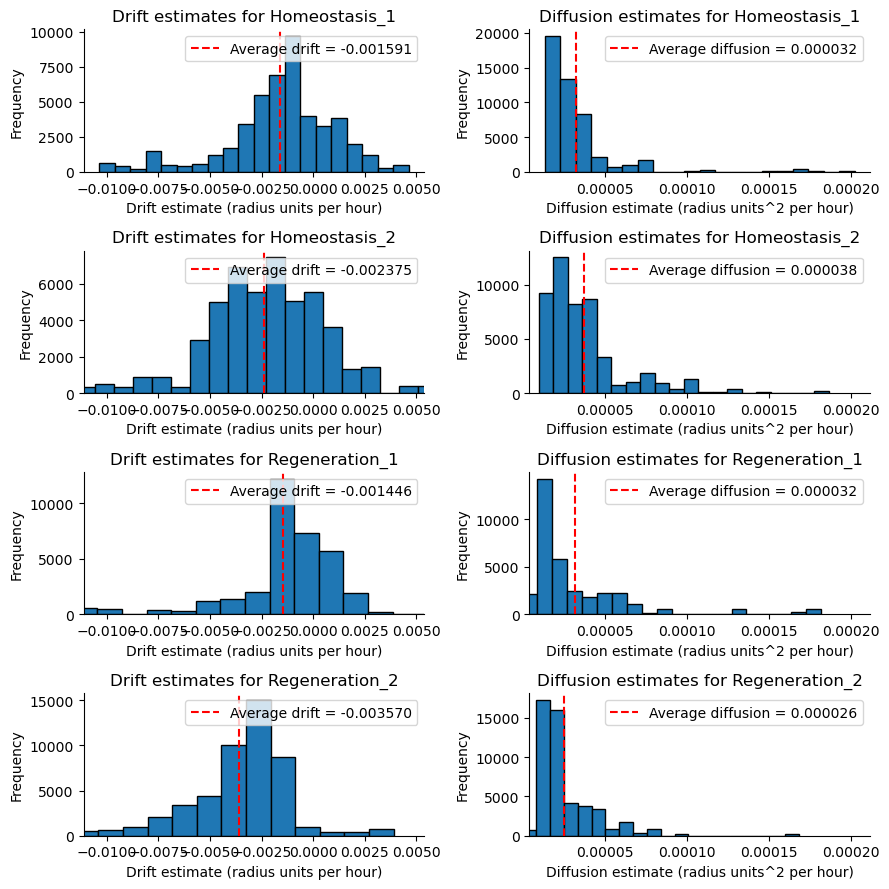

Calculating drift and diffusion estimates for time interval of 20 time steps (6.67 hours)
Homeostasis_1: Estimated drift = -0.001613 radius units per hour, Estimated diffusion = 0.000032 radius units^2 per hour
Homeostasis_1: With drift alone, at this rate, it would take 620.15 hours, i.e. 25.84 days for a neuron to cross the jellyfish
Homeostasis_1: typical cohort size = 85.13 neurons
Homeostasis_2: Estimated drift = -0.002391 radius units per hour, Estimated diffusion = 0.000035 radius units^2 per hour
Homeostasis_2: With drift alone, at this rate, it would take 418.22 hours, i.e. 17.43 days for a neuron to cross the jellyfish
Homeostasis_2: typical cohort size = 96.17 neurons
Regeneration_1: Estimated drift = -0.001129 radius units per hour, Estimated diffusion = 0.000027 radius units^2 per hour
Regeneration_1: With drift alone, at this rate, it would take 885.90 hours, i.e. 36.91 days for a neuron to cross the jellyfish
Regeneration_1: typical cohort size = 108.40 neurons
Regenerat

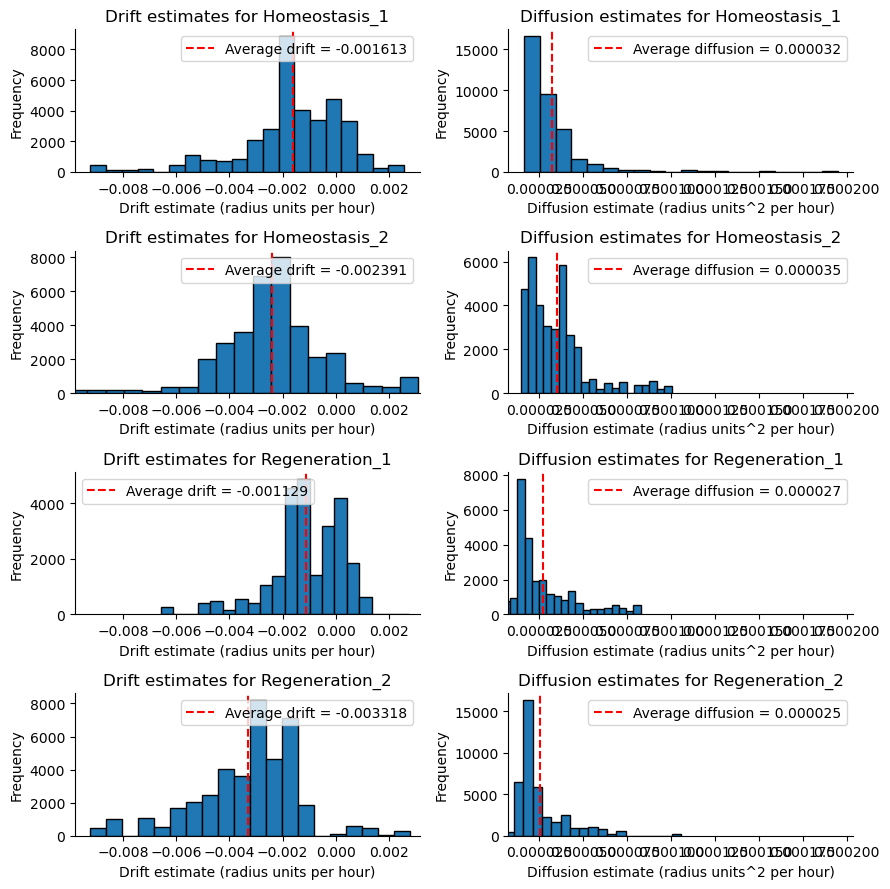

Calculating drift and diffusion estimates for time interval of 30 time steps (10.00 hours)
Homeostasis_1: Estimated drift = -0.001486 radius units per hour, Estimated diffusion = 0.000031 radius units^2 per hour
Homeostasis_1: With drift alone, at this rate, it would take 672.88 hours, i.e. 28.04 days for a neuron to cross the jellyfish
Homeostasis_1: typical cohort size = 127.35 neurons
Homeostasis_2: Estimated drift = -0.002482 radius units per hour, Estimated diffusion = 0.000033 radius units^2 per hour
Homeostasis_2: With drift alone, at this rate, it would take 402.91 hours, i.e. 16.79 days for a neuron to cross the jellyfish
Homeostasis_2: typical cohort size = 138.21 neurons
Regeneration_1: Estimated drift = -0.001143 radius units per hour, Estimated diffusion = 0.000026 radius units^2 per hour
Regeneration_1: With drift alone, at this rate, it would take 875.11 hours, i.e. 36.46 days for a neuron to cross the jellyfish
Regeneration_1: typical cohort size = 150.13 neurons
Regene

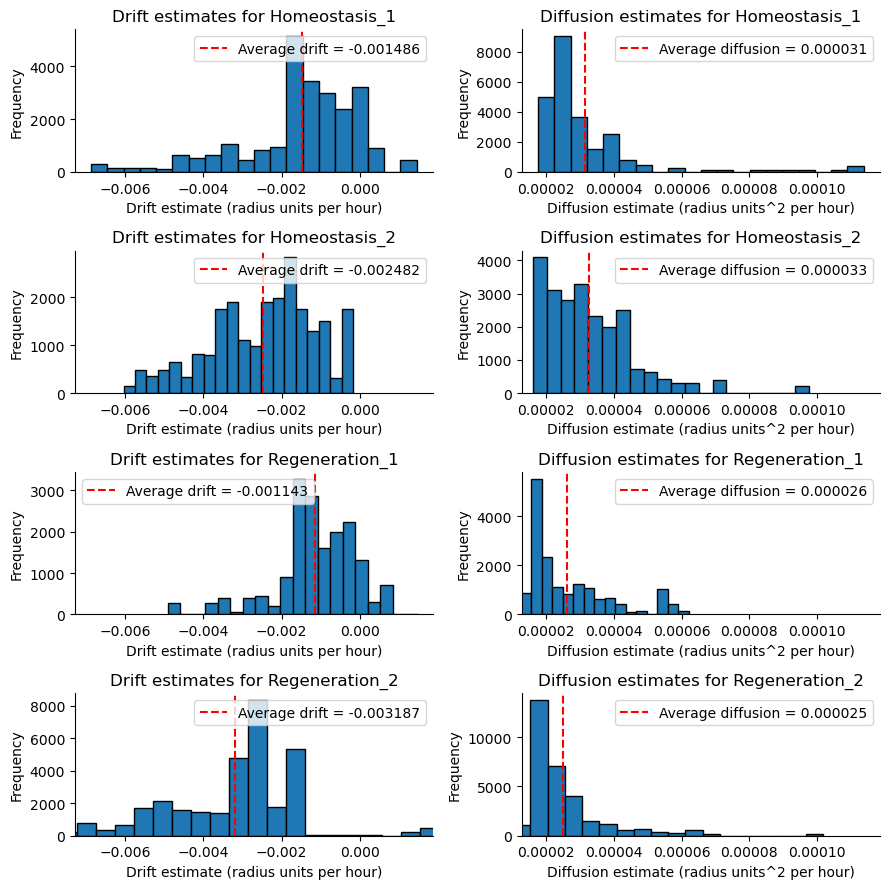

Calculating drift and diffusion estimates for time interval of 40 time steps (13.33 hours)
Homeostasis_1: Estimated drift = -0.001219 radius units per hour, Estimated diffusion = 0.000032 radius units^2 per hour
Homeostasis_1: With drift alone, at this rate, it would take 820.59 hours, i.e. 34.19 days for a neuron to cross the jellyfish
Homeostasis_1: typical cohort size = 169.79 neurons
Homeostasis_2: Estimated drift = -0.002486 radius units per hour, Estimated diffusion = 0.000033 radius units^2 per hour
Homeostasis_2: With drift alone, at this rate, it would take 402.24 hours, i.e. 16.76 days for a neuron to cross the jellyfish
Homeostasis_2: typical cohort size = 180.72 neurons
Regeneration_1: Estimated drift = -0.001352 radius units per hour, Estimated diffusion = 0.000028 radius units^2 per hour
Regeneration_1: With drift alone, at this rate, it would take 739.41 hours, i.e. 30.81 days for a neuron to cross the jellyfish
Regeneration_1: typical cohort size = 192.24 neurons
Regene

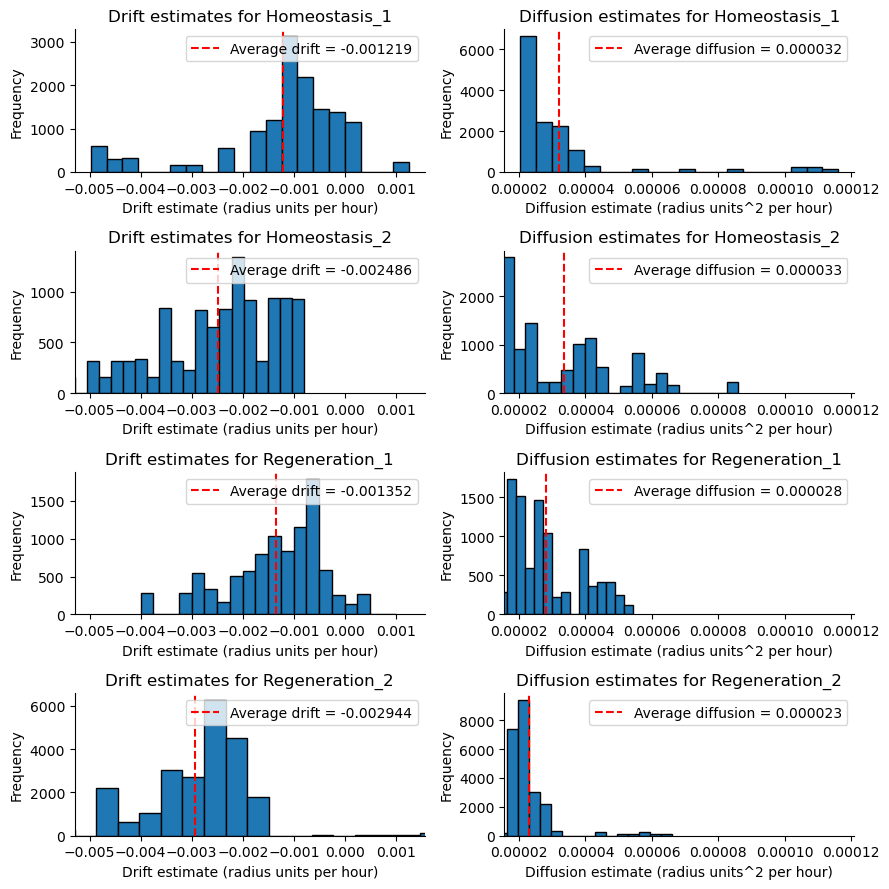

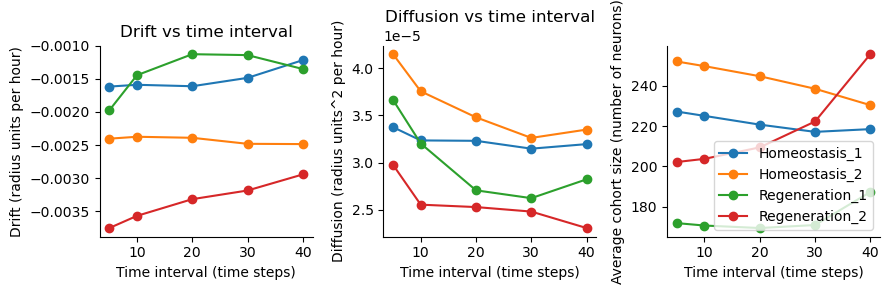

In [12]:
# next step: calculate drift and difusion rates
# while in reality, this may be a function of radius and time, for simplicity, we will assume constant

# here's a hacky way to do this:
# for a pair of time points, we can pick a cohort of neurons that are alive at both time points,
# then calculate their radial displacements and the variance of their radial displacements,
#  which gives us an estimate of the drift and diffusion coefficients, respectively. 
#  We can repeat this for multiple pairs of time points and average the results to get more robust estimates.

# because individual snapshots are noisy, we want to do this for relatively long time intervals 


timestep_skips = [5, 10, 20, 30, 40]  # divide by 3 to get hours

drifts = np.zeros((len(timestep_skips), len(datasets)))
diffusions = np.zeros((len(timestep_skips), len(datasets)))
cohort_sizes = np.zeros((len(timestep_skips), len(datasets)))

for i, n_timesteps_skip in enumerate(timestep_skips):
    fig, axs = plt.subplots(n_datasets,2, figsize = (9,9))
    print(f"Calculating drift and diffusion estimates for time interval of {n_timesteps_skip} time steps ({n_timesteps_skip/3:.2f} hours)")

    for j, dataset in enumerate(datasets):
        neurons = neuron_dfs[dataset]
        r_max = neurons["r"].max()
        neurons["r_norm"] = neurons["r"] / r_max  # normalize radius by max
        time_points = neurons["real_time"].dropna().unique()
        time_points.sort()

        drift_estimates = []
        diffusion_estimates = []
        cohort_sizes_local = []
        for t in range(len(time_points) - n_timesteps_skip):
            t1 = time_points[t]
            t2 = time_points[t + n_timesteps_skip]
            time_diffs = np.diff(time_points[t:t + n_timesteps_skip + 1])
            if np.max(time_diffs) > 1.0:  # skip if this set of time intervals includes a gap of larger than 1 hour. this excludes the 8 hour gaps when the jellyfish is recovering off-scope 
                continue
            cohort = neurons[(neurons["real_time"] == t1) & (neurons["track_id"].isin(neurons[neurons["real_time"] == t2]["track_id"]))]
            cohort_sizes_local.append(len(cohort))
            if len(cohort) > 0:
                r1 = cohort["r_norm"].to_numpy()
                r2 = neurons[(neurons["real_time"] == t2) & (neurons["track_id"].isin(cohort["track_id"]))]["r_norm"].to_numpy()
                dr = r2 - r1
                dt = t2 - t1
                drift_estimates.append(np.mean(dr / dt))
                diffusion_estimates.append(np.var(dr) / (2 * dt))

        # compute the average drift and diffusion estimates, weighted by cohort size, and print results
        drift_avg = np.average(drift_estimates, weights=cohort_sizes_local)
        diffusion_avg = np.average(diffusion_estimates, weights=cohort_sizes_local)
        print(f"{dataset}: Estimated drift = {drift_avg:.6f} radius units per hour, Estimated diffusion = {diffusion_avg:.6f} radius units^2 per hour")
        crossing_time_hours = -1 / drift_avg 
        crossing_time_days = crossing_time_hours / 24
        print(f"{dataset}: With drift alone, at this rate, it would take {crossing_time_hours:.2f} hours, i.e. {crossing_time_days:.2f} days for a neuron to cross the jellyfish")
        print(f"{dataset}: typical cohort size = {np.mean(cohort_sizes):.2f} neurons")

        drifts[i, j] = drift_avg
        diffusions[i, j] = diffusion_avg
        cohort_sizes[i, j] = np.mean(cohort_sizes_local)

        
        axs[j, 0].hist(drift_estimates, bins=20, edgecolor='k', weights=cohort_sizes_local)
        axs[j, 0].axvline(x=drift_avg, color='r', linestyle='--', label=f"Average drift = {drift_avg:.6f}")
        axs[j, 0].set_xlabel("Drift estimate (radius units per hour)")
        axs[j, 0].set_ylabel("Frequency")
        axs[j, 0].set_title(f"Drift estimates for {dataset}")
        axs[j, 0].legend()
        axs[j, 0].sharex(axs[0,0])
        axs[j, 1].hist(diffusion_estimates, bins=20, edgecolor='k', weights=cohort_sizes_local)
        axs[j, 1].axvline(x=diffusion_avg, color='r', linestyle='--', label=f"Average diffusion = {diffusion_avg:.6f}")
        axs[j, 1].set_xlabel("Diffusion estimate (radius units^2 per hour)")
        axs[j, 1].set_ylabel("Frequency")
        axs[j, 1].set_title(f"Diffusion estimates for {dataset}")
        axs[j, 1].legend()
        axs[j, 1].sharex(axs[0,1])
        plt.tight_layout()
        sns.despine()
    plt.show()


fig, axs = plt.subplots(1,3, figsize = (9, 3))
axs[0].plot(timestep_skips, drifts, marker="o")
axs[0].set_xlabel("Time interval (time steps)")
axs[0].set_ylabel("Drift (radius units per hour)")
axs[0].set_title("Drift vs time interval")
axs[1].plot(timestep_skips, diffusions, marker="o")
axs[1].set_xlabel("Time interval (time steps)") 
axs[1].set_ylabel("Diffusion (radius units^2 per hour)")
axs[1].set_title("Diffusion vs time interval")
axs[2].plot(timestep_skips, cohort_sizes, marker="o")
axs[2].set_xlabel("Time interval (time steps)")
axs[2].set_ylabel("Average cohort size (number of neurons)")    
axs[2].legend(datasets)
plt.tight_layout()
sns.despine()


In [13]:
# Now, lets pick some overall estimatates. 
# parameters seem reatively flat from 20 - 30 timesteps. Since 30 timesteps corresponds to 10 hours, which is a reasonable timescale over which to assume constant drift and diffusion, we will pick the estimates from the 30 timestep interval as our overall estimates.

drift_ests = drifts[3, :]
diffusion_ests = diffusions[3, :]

overall_drift = drift_ests.mean()
overall_diffusion = diffusion_ests.mean()

print(f"Overall estimated drift = {overall_drift:.6f} radius units per hour, Overall estimated diffusion = {overall_diffusion:.6f} radius units^2 per hour")


Overall estimated drift = -0.002074 radius units per hour, Overall estimated diffusion = 0.000029 radius units^2 per hour


## snapshots of time - evolution 
Plot snapshots of neuron, birth distributions over time 

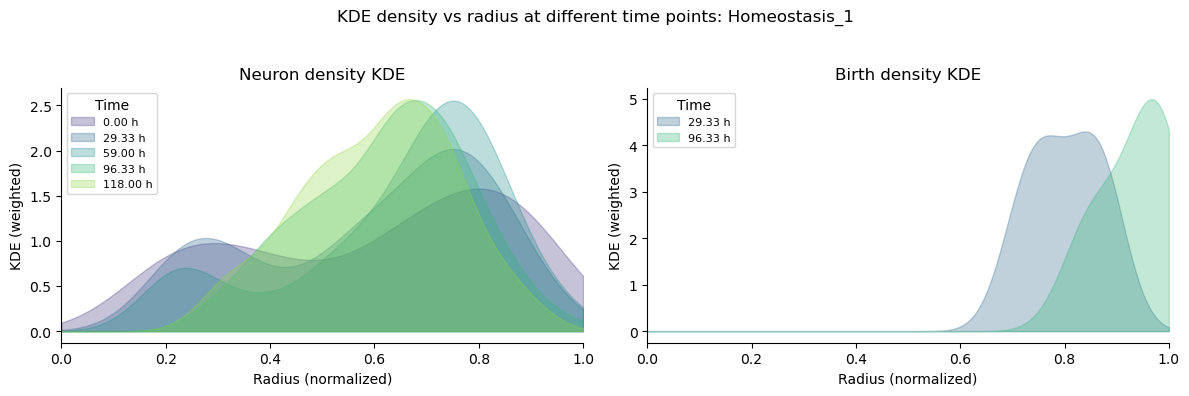

/var/folders/87/w43tb79n67n08xyspfl0n8390zhhg9/T/ipykernel_65386/2074422541.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(title="Time", fontsize=8)


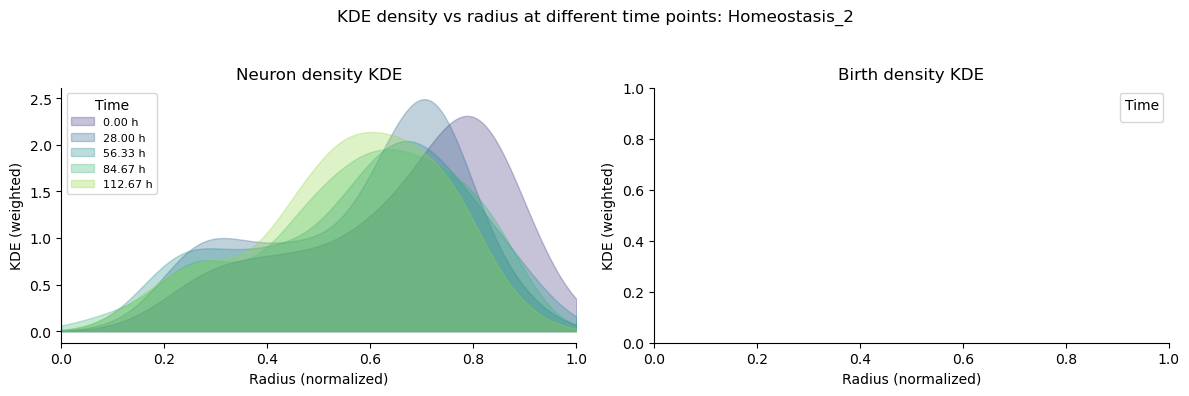

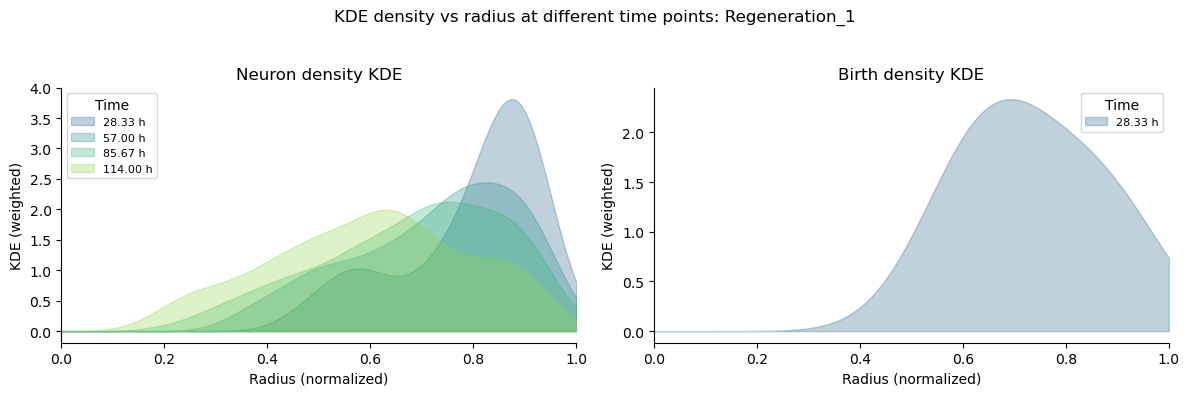

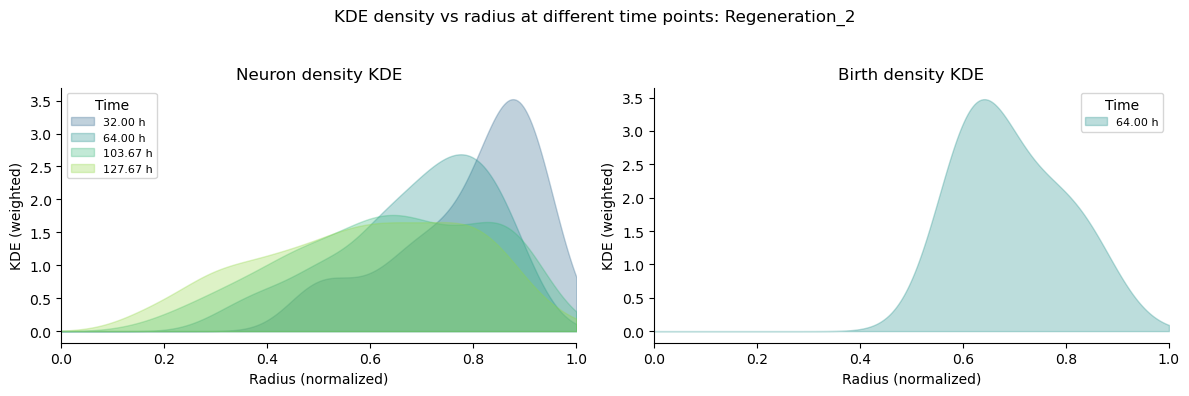

In [14]:
from scipy.stats import gaussian_kde

#get density of births, neurons as a funciton of radius 
# plot for snapshot of times, with a kde
for dataset in datasets:
    data = radial_density[dataset]
    neurons = neuron_dfs[dataset]
    births =  birth_datasets[dataset]
    r_max = data["r_max"]  # use stored r_max for consistent normalization

    times = data["time_points"]
    time_indices = [0, len(times)//4, len(times)//2, 3*len(times)//4, -1]

    fig = plt.figure(figsize=(12, 4))
    axs = fig.subplots(1, 2)
    fig.suptitle(f"KDE density vs radius at different time points: {dataset}")

    colors = sns.color_palette("viridis", n_colors=len(time_indices))
    x_eval = np.linspace(0, 1, 300)

    neurons["r_norm"] = neurons["r"] / r_max
    births["r_norm"] = births["r"] / r_max

    for idx, color in zip(time_indices, colors):
        time = times[idx]
        neuron_r_vals = neurons.loc[neurons["real_time"] == time, "r_norm"].values
        birth_r_vals = births.loc[births["real_time"] == time, "r_norm"].values


        if len(neuron_r_vals) > 1:
            kde_neuron = gaussian_kde(neuron_r_vals, weights=None)
            axs[0].fill_between(
                x_eval, kde_neuron(x_eval),
                color=color, alpha=0.30, label=f"{time:.2f} h"
            )

        if len(birth_r_vals) > 1:
            kde_birth = gaussian_kde(birth_r_vals, weights=None)
            axs[1].fill_between(
                x_eval, kde_birth(x_eval),
                color=color, alpha=0.30, label=f"{time:.2f} h"
            )
    axs[0].set_xlabel("Radius (normalized)")
    axs[0].set_ylabel("KDE (weighted)")
    axs[0].set_title("Neuron density KDE")
    axs[0].set_xlim(0, 1)
    axs[0].legend(title="Time", fontsize=8)

    axs[1].set_xlabel("Radius (normalized)")
    axs[1].set_ylabel("KDE (weighted)")
    axs[1].set_title("Birth density KDE")
    axs[1].set_xlim(0, 1)
    axs[1].legend(title="Time", fontsize=8)

    sns.despine()
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


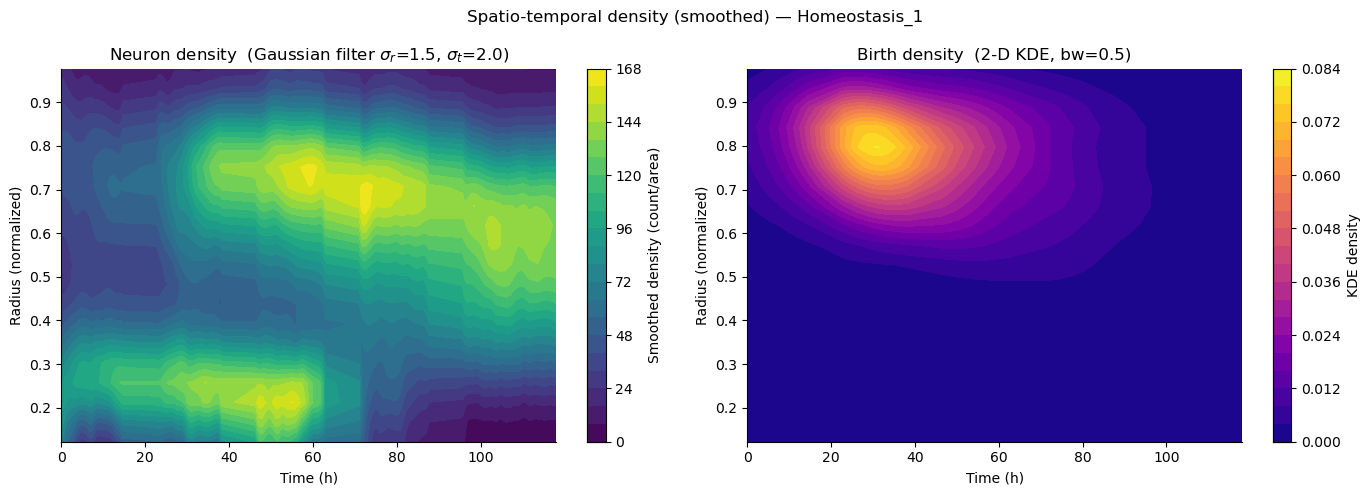

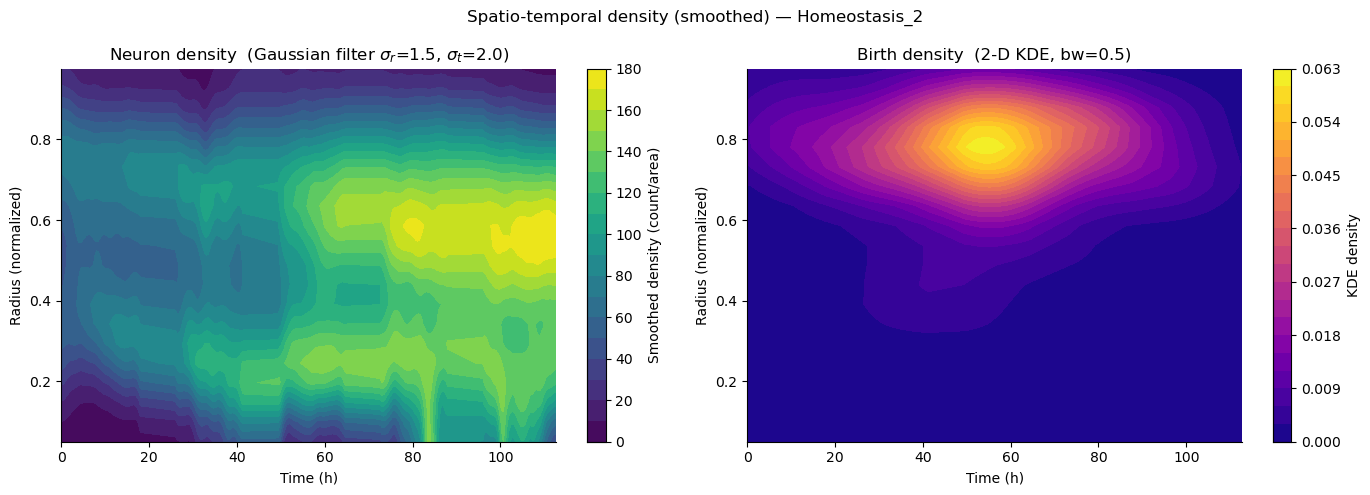

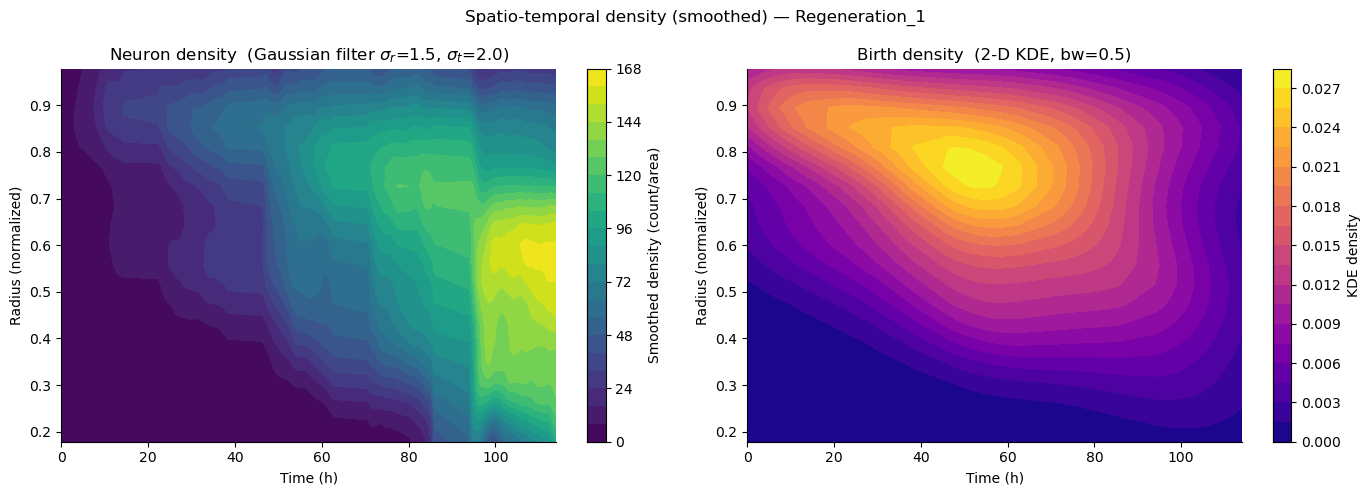

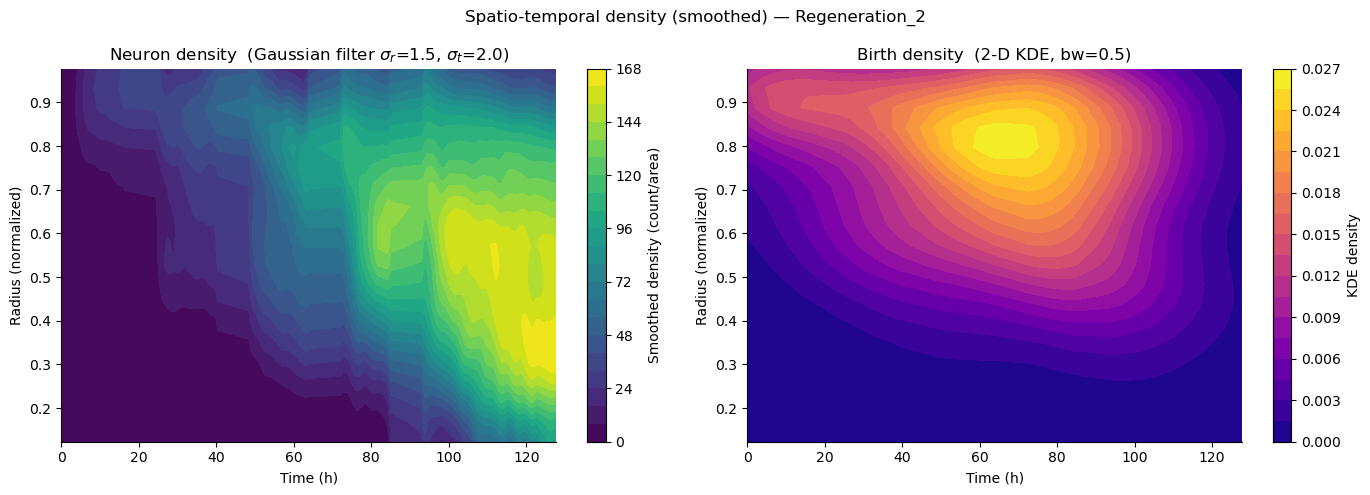

In [15]:
from scipy.ndimage import gaussian_filter
from scipy.stats import gaussian_kde

# ── Smoothing parameters ────────────────────────────────────────────────────
sigma_r = 1.5   # Gaussian smoothing bandwidth for neuron density (radial-bin units)
sigma_t = 2.0   # Gaussian smoothing bandwidth for neuron density (time-bin units)
kde_bw  = 0.5   # bandwidth for birth 2-D KDE

for dataset in datasets:
    data        = radial_density[dataset]
    time_points = data["time_points"]
    bin_centers = data["bin_centers"]  # already normalized
    neuron_hist = data["neuron_hist"]   # (n_t, n_r), count/area
    r_max       = data["r_max"]

    r_norm = bin_centers  # already normalized

    # ── Neuron density: smooth the per-timepoint histogram ─────────────────
    neuron_smooth = gaussian_filter(neuron_hist.astype(float), sigma=[sigma_t, sigma_r])
    data["neuron_smooth"] = neuron_smooth   # (n_t, n_r)

    # ── Birth density: 2-D KDE on raw event positions ─────────────────────
    births  = birth_datasets[dataset]
    t_b     = births["real_time"].values
    r_b     = births["r"].values / r_max

    # evaluation grid matching the neuron plot axes
    t_grid, r_grid = np.meshgrid(time_points, r_norm)   # each (n_r, n_t)

    if len(r_b) > 1:
        kde = gaussian_kde(
            np.vstack([t_b, r_b]),
            bw_method=kde_bw,
        )
        birth_smooth = kde(np.vstack([t_grid.ravel(), r_grid.ravel()])).reshape(t_grid.shape)
    else:
        birth_smooth = np.zeros_like(t_grid)
    data["birth_smooth"] = birth_smooth.T   # store as (n_t, n_r) to match neuron_smooth
    data["r_norm"] = r_norm

    # ── Plot ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Spatio-temporal density (smoothed) — {dataset}", fontsize=12)

    im0 = axes[0].contourf(
        time_points, r_norm, neuron_smooth.T,
        levels=20, cmap="viridis"
    )
    plt.colorbar(im0, ax=axes[0], label="Smoothed density (count/area)")
    axes[0].set_xlabel("Time (h)")
    axes[0].set_ylabel("Radius (normalized)")
    axes[0].set_title(f"Neuron density  (Gaussian filter $\\sigma_r$={sigma_r}, $\\sigma_t$={sigma_t})")

    im1 = axes[1].contourf(
        time_points, r_norm, birth_smooth,
        levels=20, cmap="plasma"
    )
    plt.colorbar(im1, ax=axes[1], label="KDE density")
    axes[1].set_xlabel("Time (h)")
    axes[1].set_ylabel("Radius (normalized)")
    axes[1].set_title(f"Birth density  (2-D KDE, bw={kde_bw})")

    sns.despine()
    plt.tight_layout()
    plt.show()


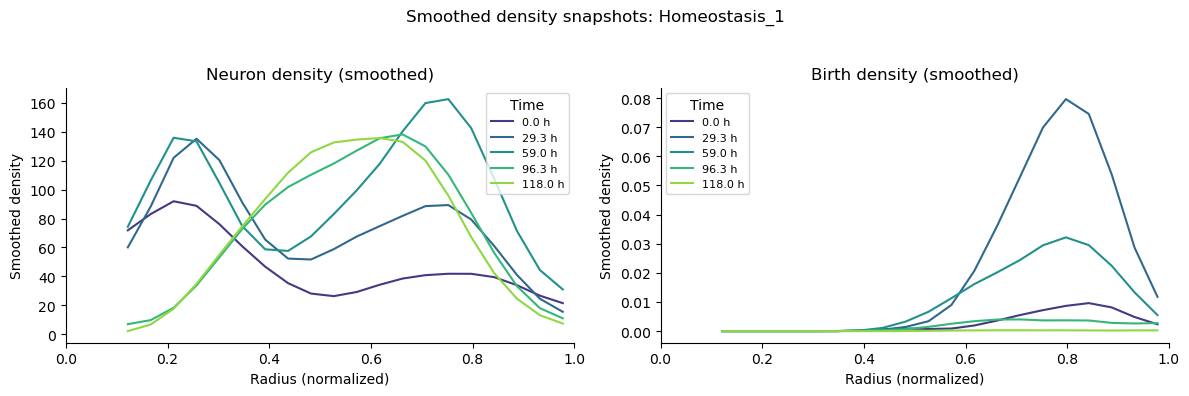

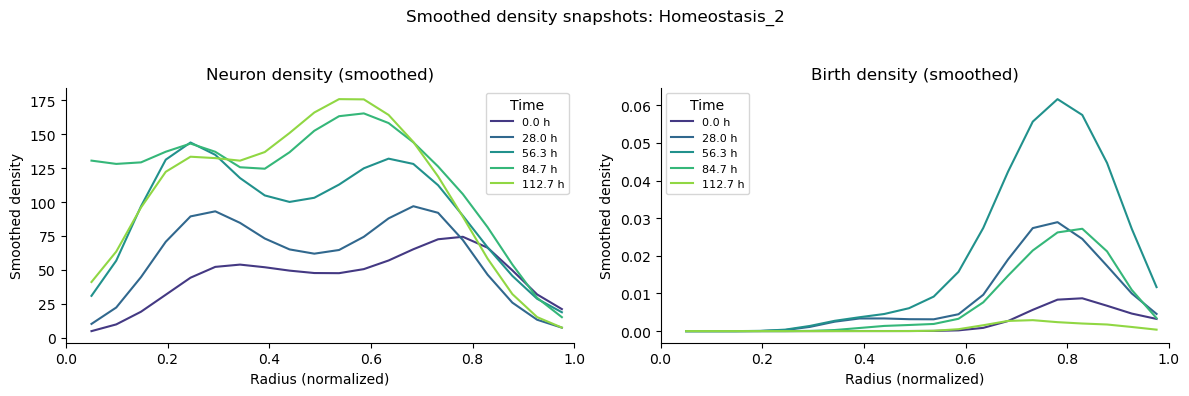

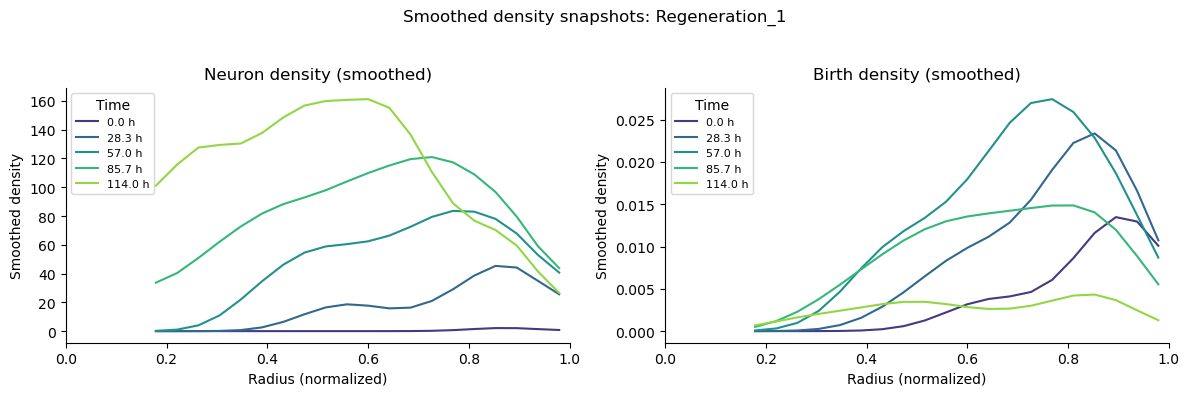

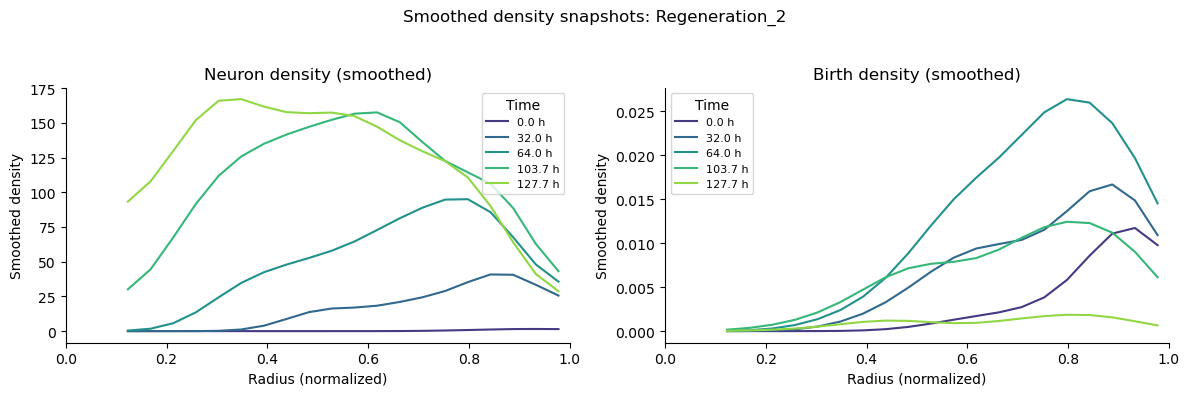

In [16]:
# Snapshot slices from the smoothed density surfaces
for dataset in datasets:
    data        = radial_density[dataset]
    time_points = data["time_points"]
    r_norm      = data["r_norm"]
    neuron_smooth = data["neuron_smooth"]   # (n_t, n_r)
    birth_smooth  = data["birth_smooth"]    # (n_t, n_r)

    time_indices = [0, len(time_points)//4, len(time_points)//2, 3*len(time_points)//4, -1]
    colors = sns.color_palette("viridis", n_colors=len(time_indices))

    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Smoothed density snapshots: {dataset}")

    for idx, color in zip(time_indices, colors):
        t = time_points[idx]
        axs[0].plot(r_norm, neuron_smooth[idx], color=color, alpha=1, label=f"{t:.1f} h")
        axs[1].plot(r_norm, birth_smooth[idx],  color=color, alpha=1, label=f"{t:.1f} h")

    for ax, title in zip(axs, ["Neuron density (smoothed)", "Birth density (smoothed)"]):
        ax.set_xlabel("Radius (normalized)")
        ax.set_ylabel("Smoothed density")
        ax.set_title(title)
        ax.set_xlim(0, 1)
        ax.legend(title="Time", fontsize=8)

    sns.despine()
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


In [17]:
# from matplotlib.animation import FuncAnimation

# gif_path = "../results/smoothed_density_evolution_all_datasets.gif"
# fps = 15

# # ── Collect per-dataset data ───────────────────────────────────────────────
# # All datasets may have different numbers of timepoints; we animate the
# # union of frames by iterating each dataset's own time axis independently.
# palette = sns.color_palette("colorblind", n_datasets)

# # Find the dataset with the most timepoints to set frame count
# n_frames = max(len(radial_density[ds]["time_points"]) for ds in datasets)

# fig, axes = plt.subplots(n_datasets, 2, figsize=(12, 3 * n_datasets))
# fig.suptitle("Smoothed radial density over time", fontsize=13)

# # Pre-compute y-axis limits across all datasets and all times
# neuron_ymax = max(radial_density[ds]["neuron_smooth"].max() for ds in datasets) * 1.1
# birth_ymax  = max(radial_density[ds]["birth_smooth"].max()  for ds in datasets) * 1.1

# # Create one line per dataset on each axis
# lines_n = []
# lines_b = []
# time_texts = []

# for j, dataset in enumerate(datasets):
#     color = palette[j]
#     ln, = axes[j, 0].plot([], [], color=color, lw=2)
#     lb, = axes[j, 1].plot([], [], color=color, lw=2)
#     lines_n.append(ln)
#     lines_b.append(lb)

#     r_norm = radial_density[dataset]["r_norm"]
#     axes[j, 0].set_xlim(r_norm[0], r_norm[-1])
#     axes[j, 0].set_ylim(0, neuron_ymax)
#     axes[j, 0].set_ylabel("Density")
#     axes[j, 0].set_title(f"{dataset} — neurons")

#     axes[j, 1].set_xlim(r_norm[0], r_norm[-1])
#     axes[j, 1].set_ylim(0, birth_ymax)
#     axes[j, 1].set_title(f"{dataset} — births")

#     txt = axes[j, 0].text(0.02, 0.93, "", transform=axes[j, 0].transAxes, fontsize=9)
#     time_texts.append(txt)

# for ax in axes[:, 0]:
#     ax.set_xlabel("Radius (normalized)")
# for ax in axes[:, 1]:
#     ax.set_xlabel("Radius (normalized)")

# sns.despine()
# plt.tight_layout()


# def update(frame):
#     for j, dataset in enumerate(datasets):
#         data   = radial_density[dataset]
#         tpts   = data["time_points"]
#         n_t    = len(tpts)
#         # map global frame index proportionally to this dataset's time axis
#         t_idx  = min(int(frame * n_t / n_frames), n_t - 1)
#         r_norm = data["r_norm"]

#         lines_n[j].set_data(r_norm, data["neuron_smooth"][t_idx])
#         lines_b[j].set_data(r_norm, data["birth_smooth"][t_idx])
#         time_texts[j].set_text(f"t = {tpts[t_idx]:.1f} h")
#     return lines_n + lines_b + time_texts


# ani = FuncAnimation(fig, update, frames=n_frames, interval=1000 / fps, blit=True)
# ani.save(gif_path, writer="pillow", fps=fps)
# plt.close(fig)
# print(f"Saved: {gif_path}")


In [18]:
from matplotlib import colors as mcolors
from matplotlib.animation import FuncAnimation
from matplotlib.colors import LinearSegmentedColormap


gif_dir = "../results/"
fps = 20
n_frames = 300 # frames per GIF (subsampled from full time series)

# Polar-to-Cartesian grid (assumed radially symmetric)
theta_grid = np.linspace(0, 2 * np.pi, 120)

for dataset in datasets:
    data        = radial_density[dataset]
    time_points = data["time_points"]
    r_norm      = data["r_norm"]          # shape (n_r,), already normalized
    neuron_smooth = data["neuron_smooth"] # shape (n_t, n_r)
    birth_smooth  = data["birth_smooth"]  # shape (n_t, n_r)

    # Subsample time axis
    sample_indices = np.linspace(0, len(time_points) - 1, n_frames, dtype=int)

    # Cartesian grid for circular plot
    x_vals = r_norm * np.cos(theta_grid[:, None])  # (n_theta, n_r)
    y_vals = r_norm * np.sin(theta_grid[:, None])  # (n_theta, n_r)

    # Global color normalization (stable across frames)
    norm_N = mcolors.Normalize(vmin=neuron_smooth.min(), vmax=neuron_smooth.max())
    norm_B = mcolors.Normalize(vmin=birth_smooth.min(),  vmax=birth_smooth.max())
  #  cmap_N =  sns.color_palette("rocket", as_cmap=True)
    GIF_COL_N = '#39FF14'   # neon green  – neurons (GFP)
    cmap_N = LinearSegmentedColormap.from_list('black_to_neon', ['black', GIF_COL_N])

    cmap_B = 'gist_gray'


    fig, (axB, axN) = plt.subplots(1, 2, figsize=(7, 3.2))
    fig.subplots_adjust(left=-0.05, right=.9, wspace=0.0, bottom=0.05, top=0.8)
    fig.suptitle(f" {dataset}", fontsize=13)


    cbarB = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm_B, cmap="gray"),
    ax=axB, label="P", fraction=0.046, pad=0.02
    )
    cbarN = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm_N, cmap=cmap_N),
        ax=axN, label="N", fraction=0.046, pad=0.02
    )

    # Move left plot and its colorbar further left
    shift = 0.04
    posB = axB.get_position()
    cposB = cbarB.ax.get_position()
    axB.set_position([posB.x0 - shift, posB.y0, posB.width, posB.height])
    cbarB.ax.set_position([cposB.x0 - shift, cposB.y0, cposB.width, cposB.height])

    def update(frame_idx, axN=axN, axB=axB):
        t_idx = sample_indices[frame_idx]
        t_val = time_points[t_idx]

        axN.clear()
        axB.clear()

        N_plot = np.tile(neuron_smooth[t_idx], (len(theta_grid), 1))
        B_plot = np.tile(birth_smooth[t_idx],  (len(theta_grid), 1))

        axN.contourf(x_vals, y_vals, N_plot, levels=25, cmap=cmap_N, norm=norm_N)
        axB.contourf(x_vals, y_vals, B_plot, levels=25, cmap=cmap_B, norm=norm_B)

        for ax, title in ((axN, f"Neuron density, t={t_val:.0f} h"),
                          (axB, f"Birth density,  t={t_val:.0f} h")):
            ax.set_aspect("equal")
            ax.set_axis_off()
            ax.set_title(title, fontsize=16)

    ani = FuncAnimation(fig, update, frames=n_frames, interval=1000 / fps, blit=False)
    gif_path = f"{gif_dir}smoothed_density_circular_{dataset}.gif"
    ani.save(gif_path, writer="pillow", fps=fps)
    plt.close(fig)
    print(f"Saved: {gif_path}")


Saved: ../results/smoothed_density_circular_Homeostasis_1.gif
Saved: ../results/smoothed_density_circular_Homeostasis_2.gif
Saved: ../results/smoothed_density_circular_Regeneration_1.gif
Saved: ../results/smoothed_density_circular_Regeneration_2.gif
